In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [ ]:
import sys

sys.path.append("..")

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [11]:
directory = "/restricteddata/ukaea/gyrokinetics/raw/cyclone4_2_2"

In [12]:
def force_aspect(ax, aspect=1):
    im = ax.get_images()
    extent = im[0].get_extent()
    ax.set_aspect(abs((extent[1] - extent[0]) / (extent[3] - extent[2])) / aspect)

## Data visualization

In [ ]:
def velocity_space_sample_3D(x, title=""):
    labels = [r"v_{par}", r"v_{\mu}", r"s", r"k_x", r"k_y"]

    fig = plt.figure(figsize=(20, 20))
    fig.suptitle(title)

    fixed_axes = (2, 3, 4)
    slice_axes = (0, 1)

    global_min = np.inf
    global_max = -np.inf

    npar, nmu = 8, 2
    slice_idx = [
        [int(v_par), int(v_mu)]
        for v_par in np.linspace(9, 23, npar)
        for v_mu in np.linspace(1, 3, nmu)
    ]

    for idx in range(16):
        slice_point_0, slice_point_1 = slice_idx[idx]
        xx = x[slice_point_0, slice_point_1, :, :, :].numpy()
        global_min = min(global_min, xx.min())
        global_max = max(global_max, xx.max())

    cmap = "RdBu_r"

    for idx in range(16):
        ax_main = fig.add_subplot(4, 4, idx + 1, projection="3d")

        slice_point_0, slice_point_1 = slice_idx[idx]
        xx = x[slice_point_0, slice_point_1, :, :, :].numpy()

        ax_imshow = inset_axes(
            ax_main, width="30%", height="30%", loc="upper right", borderpad=-2.5
        )
        sliced_dims = x.mean(fixed_axes).T
        ax_imshow.matshow(sliced_dims, cmap="viridis", origin="lower")
        ax_imshow.scatter(slice_point_0, slice_point_1, color="red", marker="x")
        ax_imshow.set_xticks([])
        ax_imshow.set_yticks([])
        ax_imshow.grid(False)
        force_aspect(ax_imshow)

        X, Y, Z = np.meshgrid(
            np.arange(xx.shape[0]),
            np.arange(xx.shape[1]),
            np.arange(xx.shape[2]),
            indexing="ij",
        )

        scatter = ax_main.scatter(
            X.flatten(),
            Y.flatten(),
            Z.flatten(),
            c=xx.flatten(),
            cmap=cmap,
            alpha=0.4,
            vmin=global_min,
            vmax=global_max,
        )

        ax_main.set_xlabel(rf"${labels[fixed_axes[0]]}$", fontsize=20)
        ax_main.set_ylabel(rf"${labels[fixed_axes[1]]}$", fontsize=20)
        ax_main.set_zlabel(rf"${labels[fixed_axes[2]]}$", fontsize=20)

        ax_main.set_xticks([])
        ax_main.set_yticks([])
        ax_main.set_zticks([])
        ax_main.grid(False)

    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(scatter, cax=cbar_ax)

    return fig

In [ ]:
sgrid = np.loadtxt(os.path.join(directory, "sgrid"))
krho = np.loadtxt(os.path.join(directory, "krho"))
vpgr = np.loadtxt(os.path.join(directory, "vpgr.dat"))
ns = sgrid.shape[1] if len(sgrid.shape) > 1 else sgrid.shape[0]

nkx, nky = krho.shape[1], krho.shape[0]
nvpar, nmu = vpgr.shape[1], vpgr.shape[0]

with open(os.path.join(directory, "K70"), "rb") as fid:
    ff = np.fromfile(fid, dtype=np.float64)

x = np.reshape(ff, (2, nvpar, nmu, ns, nkx, nky), order="F").copy().astype("float32")


def do_ifft(x):
    x = np.ascontiguousarray(np.moveaxis(x, 0, -1))
    x = x.view(dtype=np.complex64)
    x = np.fft.fftshift(x, axes=(3, 4))
    x = np.fft.ifftn(x, axes=(3, 4))
    x = np.stack([x.real, x.imag]).squeeze().astype("float32")
    return torch.from_numpy(x)


x = do_ifft(x.copy())

_ = velocity_space_sample_3D(x[0])

In [43]:
def plot3D(
    x,
    fixed_axes=(2, 3),
    title="",
    subs_2d=(1, 1),
    subs_3d=(1, 1, 1),
    alpha=1.0,
    cmap="RdBu_r",
    bg_alpha=0.0,
    surface_slices=None,  # Number of Z-slices to show as surfaces
    edgecolor="white",  # Color of the surface grid lines
    linewidth=0.3,  # Width of the grid lines
):
    # Validate subsampling parameters
    if len(subs_2d) != 2:
        raise ValueError("subs_2d must be a tuple of length 2")
    if len(subs_3d) != 3:
        raise ValueError("subs_3d must be a tuple of length 3")

    fixed_axis1, fixed_axis2 = fixed_axes
    slice_axes = [i for i in range(5) if i not in fixed_axes]

    # Determine grid size with axis-specific subsampling
    n1, n2 = x.shape[fixed_axis1], x.shape[fixed_axis2]
    plane_indices1 = range(0, n1, subs_2d[0])
    plane_indices2 = range(0, n2, subs_2d[1])
    n_rows = len(plane_indices1)
    n_cols = len(plane_indices2)

    fig = plt.figure(figsize=(2 * len(plane_indices2), 2 * len(plane_indices1)))

    # Find global min/max for consistent coloring
    global_min = np.inf
    global_max = -np.inf
    global_mean_min = np.inf
    global_mean_max = -np.inf
    slice_means = []  # Store means for background colors

    for i in plane_indices1:
        for j in plane_indices2:
            idx = [slice(None)] * 5
            idx[fixed_axis1] = i
            idx[fixed_axis2] = j
            xx = x[tuple(idx)].numpy()
            global_min = min(global_min, xx.min())
            global_max = max(global_max, xx.max())
            slice_means.append(xx.mean())
            global_mean_min = min(global_mean_min, xx.mean())
            global_mean_max = max(global_mean_max, xx.mean())

    norm = plt.Normalize(global_mean_min, global_mean_max)

    def make_faint_color(mean_val):
        rgba = matplotlib.colormaps[cmap](norm(mean_val))
        return (rgba[0], rgba[1], rgba[2], bg_alpha)

    bg_colors = [make_faint_color(mean) for mean in slice_means]

    # Create a gridspec with no spacing between subplots
    gs = fig.add_gridspec(
        n_rows, n_cols, left=0, right=1, bottom=0, top=1, wspace=0, hspace=0
    )

    # Create all plots
    plot_idx = 0
    for i, row in enumerate(plane_indices1):
        for j, col in enumerate(plane_indices2):
            ax = fig.add_subplot(
                gs[i, j], projection="3d", facecolor=bg_colors[plot_idx], alpha=bg_alpha
            )
            plot_idx += 1

            # Get the data slice
            idx = [slice(None)] * 5
            idx[fixed_axis1] = row
            idx[fixed_axis2] = col
            xx = x[tuple(idx)].numpy()

            # Subsample the data
            xx = xx[:: subs_3d[0], :: subs_3d[1], :: subs_3d[2]]

            # Create meshgrid for X and Y
            X, Y = np.meshgrid(
                np.arange(0, xx.shape[0]), np.arange(0, xx.shape[1]), indexing="ij"
            )

            # Determine which Z-slices to plot as surfaces
            if surface_slices is None:
                # Default to showing 3 surfaces (min, middle, max)
                z_indices = [0, xx.shape[2] // 2, xx.shape[2] - 1]
            else:
                z_indices = np.linspace(0, xx.shape[2] - 1, surface_slices, dtype=int)

            # Plot each surface with decreasing alpha based on Z position
            for k, z in enumerate(z_indices):
                Z_val = np.full_like(X, z)
                ax.plot_surface(
                    X,
                    Y,
                    Z_val,
                    facecolors=matplotlib.colormaps[cmap](
                        plt.Normalize(global_min, global_max)(xx[:, :, z])
                    ),
                    edgecolor=edgecolor,  # Set grid line color
                    linewidth=linewidth,  # Set grid line width
                    alpha=alpha * (1 - 0.2 * k),  # Slightly fade further surfaces
                    shade=False,
                    zorder=z,
                )

            # Remove all axes and frames
            ax.set_axis_off()
            ax.grid(False)

    # Adjust the suptitle position to account for no padding
    fig.subplots_adjust(top=0.95 if title else 1.0)

    return fig

102.505


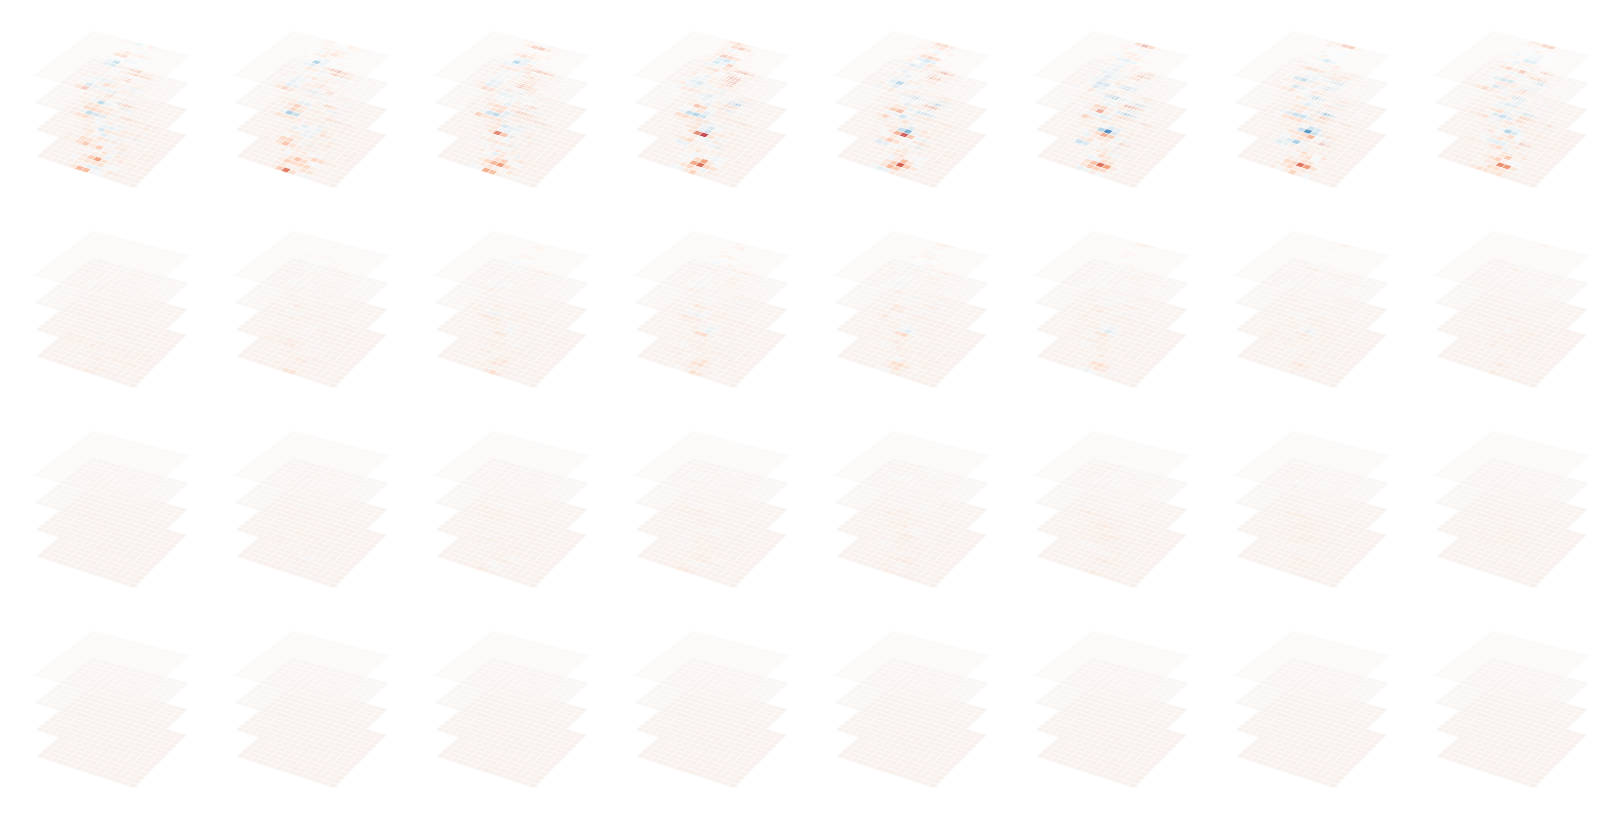

In [45]:
sgrid = np.loadtxt(os.path.join(directory, "sgrid"))
krho = np.loadtxt(os.path.join(directory, "krho"))
vpgr = np.loadtxt(os.path.join(directory, "vpgr.dat"))
time = np.loadtxt(os.path.join(directory, "time.dat"))
print(time[91 * 3])
ns = sgrid.shape[1] if len(sgrid.shape) > 1 else sgrid.shape[0]

nkx, nky = krho.shape[1], krho.shape[0]
nvpar, nmu = vpgr.shape[1], vpgr.shape[0]

with open(os.path.join(directory, "K91"), "rb") as fid:
    ff = np.fromfile(fid, dtype=np.complex128)

x = np.reshape(ff, (nvpar, nmu, ns, nkx, nky), order="F").copy()


def do_ifft(x):
    x = np.fft.fftshift(x, axes=(3, 4))
    x = np.fft.ifftn(x, axes=(3, 4))
    return torch.from_numpy(x)


x = do_ifft(x.copy()).real
# x = torch.from_numpy(x).real
x = (x - x.min()) / (x.max() - x.min())

fig = plot3D(x, fixed_axes=(1, 2), subs_2d=(2, 2), subs_3d=(2, 16, 2), surface_slices=4)
fig.savefig("vspace_projection.pdf")

In [33]:
import numpy as np
import matplotlib.colors


def plot2D_ortho(
    x,
    fixed_axes=(2, 3),
    subs_2d=(1, 1),
    cmap="RdBu_r",
    vmin=None,
    vmax=None,
    elev=30,
    azim=-45,
):
    slice_axes = [i for i in range(5) if i not in fixed_axes]
    if hasattr(x, "numpy"):
        x = x.numpy()

    projection = np.mean(x, axis=tuple(slice_axes))
    n1, n2 = projection.shape[0], projection.shape[1]

    fig = plt.figure(figsize=(20, 20))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_proj_type("ortho")
    ax.view_init(elev=elev, azim=azim)
    projection = projection[:: subs_2d[0], :: subs_2d[1]]

    X, Y = np.meshgrid(
        np.arange(0, projection.shape[0]),
        np.arange(0, projection.shape[1]),
        indexing="ij",
    )
    norm = matplotlib.colors.Normalize(
        vmin=projection.min() if vmin is None else vmin,
        vmax=projection.max() if vmax is None else vmax,
    )

    ax.plot_surface(
        X,
        Y,
        np.zeros_like(projection),
        facecolors=plt.get_cmap(cmap)(norm(projection)),
        shade=False,
        rstride=1,
        cstride=1,
    )

    ax.set_axis_off()
    return fig

102.505


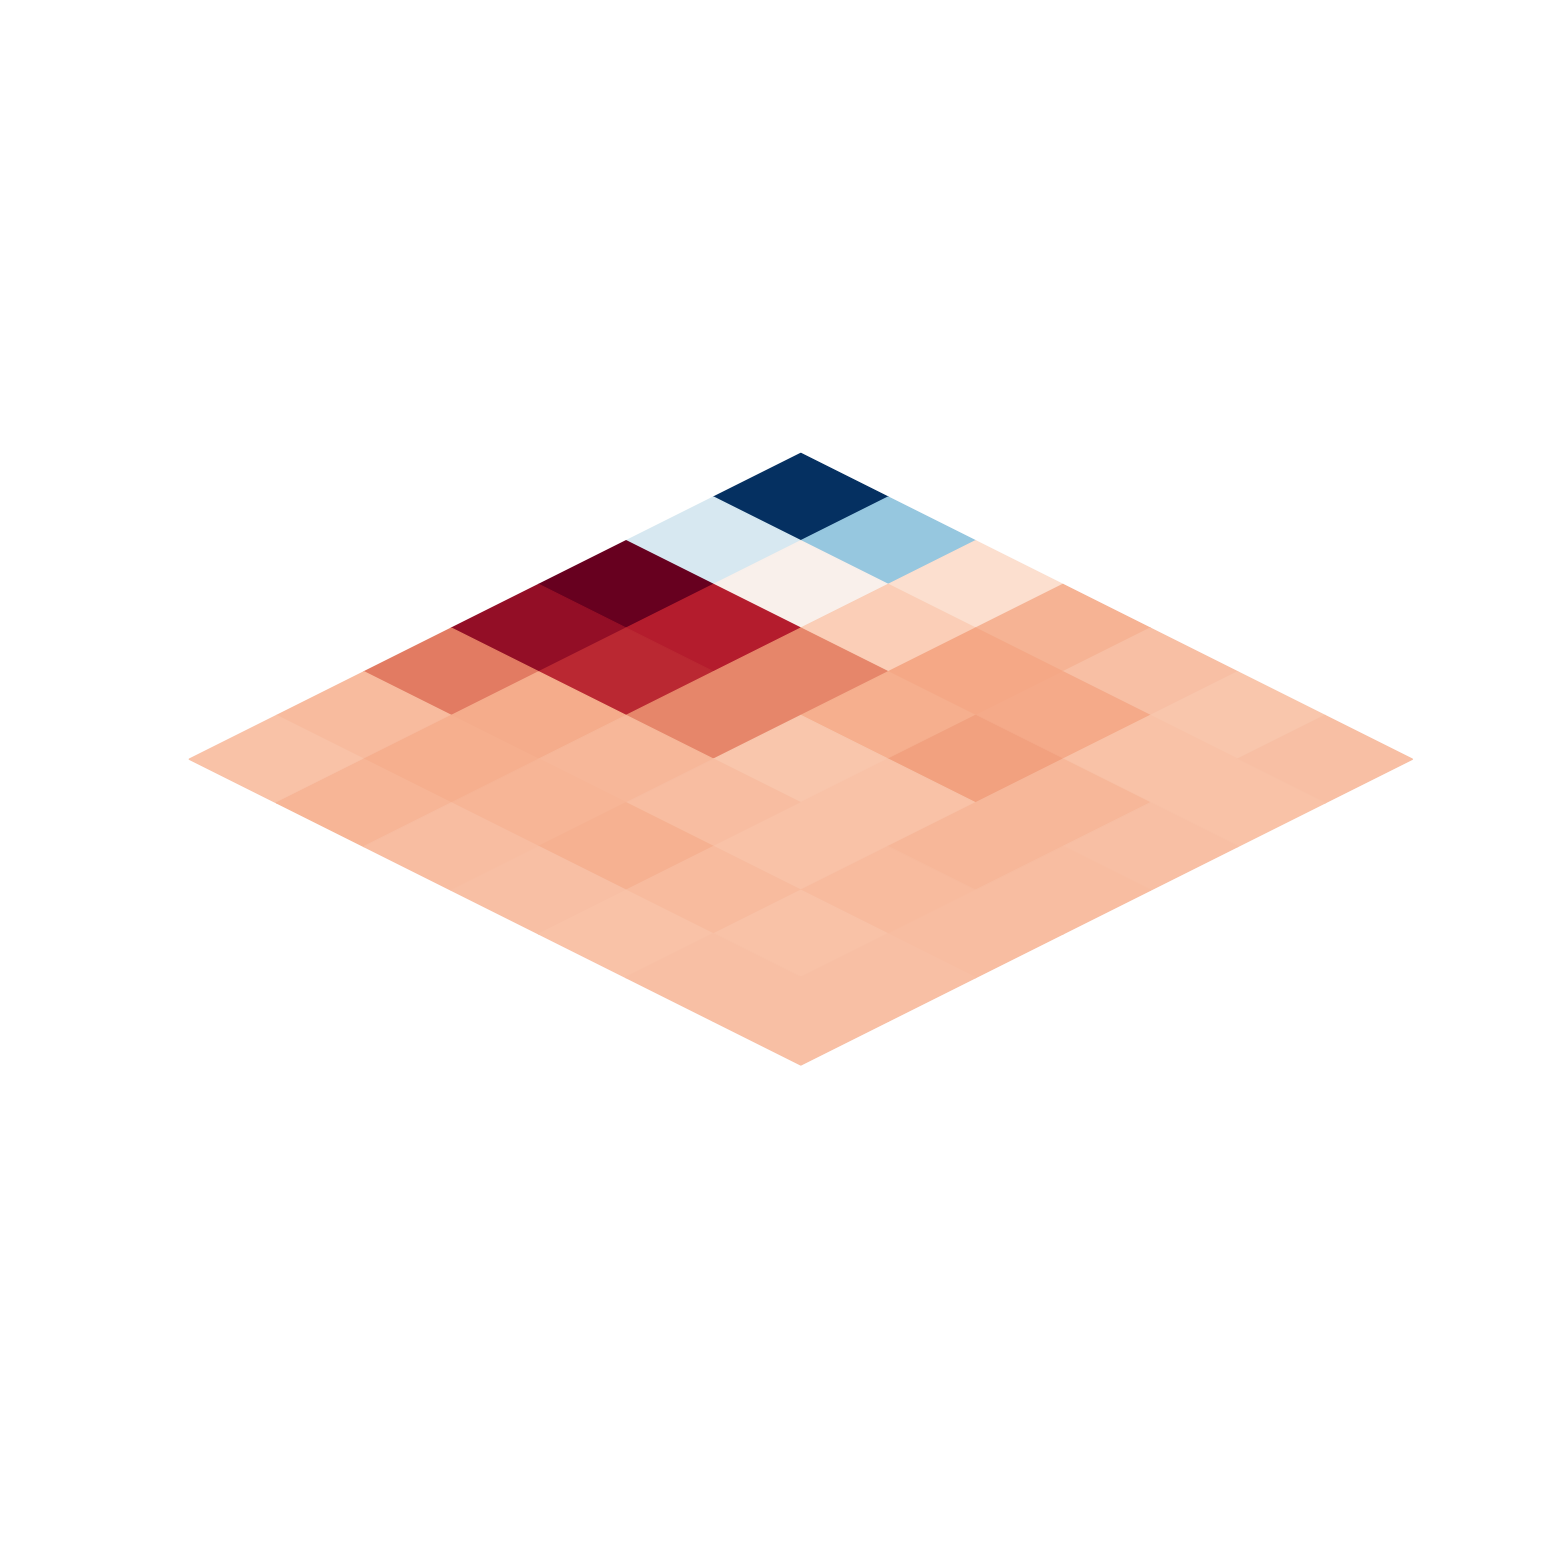

In [42]:
sgrid = np.loadtxt(os.path.join(directory, "sgrid"))
krho = np.loadtxt(os.path.join(directory, "krho"))
vpgr = np.loadtxt(os.path.join(directory, "vpgr.dat"))
time = np.loadtxt(os.path.join(directory, "time.dat"))
print(time[91 * 3])
ns = sgrid.shape[1] if len(sgrid.shape) > 1 else sgrid.shape[0]

nkx, nky = krho.shape[1], krho.shape[0]
nvpar, nmu = vpgr.shape[1], vpgr.shape[0]

with open(os.path.join(directory, "K91"), "rb") as fid:
    ff = np.fromfile(fid, dtype=np.complex128)

x = np.reshape(ff, (nvpar, nmu, ns, nkx, nky), order="F").copy()


def do_ifft(x):
    x = np.fft.fftshift(x, axes=(3, 4))
    x = np.fft.ifftn(x, axes=(3, 4))
    return torch.from_numpy(x)


x = do_ifft(x.copy()).real
# x = torch.from_numpy(x).real
x = (x - x.min()) / (x.max() - x.min())

fig = plot2D_ortho(x, fixed_axes=(1, 2), subs_2d=(1, 2))
fig.savefig("sspace.pdf", bbox_inches="tight")

In [ ]:
def force_aspect(ax, aspect=1):
    im = ax.get_images()
    extent = im[0].get_extent()
    ax.set_aspect(abs((extent[1] - extent[0]) / (extent[3] - extent[2])) / aspect)


def distribution_5D(x, **kwargs):
    _ = kwargs
    labels = [r"v_{\parallel}", r"v_{\mu}", r"s", r"x", r"y"]
    used = {}

    if isinstance(x, torch.Tensor):
        x = x.cpu().detach().numpy()

    comb = torch.combinations(torch.arange(5), 2).tolist()

    fig, ax = plt.subplots(5, 5, figsize=(20, 20))
    fig.subplots_adjust(wspace=0.02, hspace=0.02)

    for i in range(5):
        for j in range(5):
            if j == 0:
                ax[i, j].remove()
                continue
            if i == 4:
                ax[i, j].remove()
                continue
            ax_ij = ax[i, j]
            ax_ij.set_frame_on(False)
            ax_ij.tick_params(labelleft=False, labelbottom=False)
            ax_ij.set_xticks([])
            ax_ij.set_yticks([])

    c_map = matplotlib.colormaps["RdBu_r"]
    c_map.set_bad("k")

    imin = -1
    for i, j in comb:
        other = tuple([o for o in range(5) if o != i and o != j])
        xx = x.mean(other)
        xx[xx == 0] = np.nan
        ax[i, j].matshow(xx, cmap=c_map)

        if i > imin:
            ax[i, j].set_ylabel(rf"${labels[i]}$", fontsize=40)
            ax[i, j].set_xlabel(rf"${labels[j]}$", fontsize=40)
            imin = i

        # Remove axis ticks and labels
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        ax[i, j].tick_params(labelleft=False, labelbottom=False)

        force_aspect(ax[i, j])

    return fig


fig = distribution_5D(x)
fig.savefig("5d_show.pdf")

## Model visualization

In [ ]:
CKP = "/system/user/publicwork/fpaische/plasmamodelling/outputs/20250115_150422"
device = "cuda"

In [ ]:
import yaml
from omegaconf import OmegaConf

from models import get_model

from dataset.cyclone import CycloneDataset

cfg = OmegaConf.create(yaml.safe_load(open(f"{CKP}/config.yaml", "r")))

cfg.model.swin.itg_conditioning = False

data = CycloneDataset(
    active_keys=cfg.dataset.active_keys,
    split="val",
    random_seed=cfg.seed,
    normalization=cfg.dataset.normalization,
    spatial_ifft=cfg.dataset.spatial_ifft,
    bundle_seq_length=cfg.model.bundle_seq_length,
    trajectories=cfg.dataset.validation_trajectories,
)
traindata = []
print(f"Train: {len(traindata)}, Val: {len(data)}")

model = get_model(cfg, data)

loaded_ckp = torch.load(f"{CKP}/best.pth", map_location=device, weights_only=True)
model.load_state_dict(
    {k.replace("module.", ""): v for k, v in loaded_ckp["model_state_dict"].items()}
)

model = model.to(device)

In [ ]:
from tqdm import tqdm
from collections import defaultdict
import numpy as np


def mse_time_histogram(model_fn, data):
    model_fn.eval()

    losses = defaultdict(list)
    sample = data[0]
    K1 = sample.x.numpy()
    x = torch.tensor(K1).to(device).unsqueeze(0)
    with torch.no_grad():
        for idx in tqdm(range(len(data))):
            sample = data[idx]
            K2 = sample.y.numpy()
            # x = torch.tensor(K1).to(device).unsqueeze(0)
            ts = sample.timestep_index.to(device).unsqueeze(0)
            x = model_fn(x, timestep=ts)

            mse = np.mean((x.squeeze(0).cpu().detach().numpy() - K2) ** 2)
            losses[ts.squeeze().item()].append(mse)

    fig = mse_time_histogram_from_losses(losses)

    return fig, losses


def mse_time_histogram_from_losses(losses):
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    times = sorted(losses.keys())
    losses_mean = [np.mean(losses[t]) for t in times]
    losses_std = [np.std(losses[t]) for t in times]

    # Bar plot with error bars
    ax.bar(times, losses_mean, yerr=losses_std, alpha=0.7, capsize=5, color="blue")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Mean Squared Error")
    ax.set_title("MSE by Time Step")
    ax.grid(True)

    return fig

In [ ]:
_, losses = mse_time_histogram(model, data=traindata)

In [ ]:
_, val_losses = mse_time_histogram(model, data=data)

In [ ]:
_ = mse_time_histogram_from_losses(losses | val_losses)

In [ ]:
def force_aspect(ax, aspect=1):
    im = ax.get_images()
    extent = im[0].get_extent()
    ax.set_aspect(abs((extent[1] - extent[0]) / (extent[3] - extent[2])) / aspect)


def distribution_5D(model_fn, idx=0):
    labels = ["vpar", "mu", "s", "x", "y"]

    model_fn.eval()
    sample = traindata[idx]
    K2 = sample.y.numpy()
    x = sample.x.to(device).unsqueeze(0)
    ts = sample.timestep_index.to(device).unsqueeze(0)
    f = model_fn(x, timestep=ts).squeeze(0).cpu().detach().numpy()

    comb = torch.combinations(torch.arange(5), 2).tolist()

    fig, ax = plt.subplots(5, 5, figsize=(20, 20))
    c_map = colormaps["rainbow"]
    c_map.set_bad("k")

    imin = -1
    for i, j in comb:
        other = tuple([o for o in range(5) if o != i and o != j])
        xx = f[0].std(other)
        xx[xx == 0] = np.nan
        ax[i, j].matshow(xx, cmap=c_map)

        if i > imin:
            ax[i, j].set_ylabel(labels[i], fontsize=20)
            ax[i, j].set_xlabel(labels[j], fontsize=20)
            imin = i

        force_aspect(ax[i, j])

    for i in range(5):
        for j in range(5):
            if [i, j] not in comb:
                ax[i, j].remove()
    return fig

In [ ]:
fig = distribution_5D(model, 10)
# fig

In [ ]:
fig

In [ ]:
from matplotlib import animation


def animate_5D(model_fn, title="", frames=10, start=55, idx=0):
    plt.rcParams["animation.html"] = "jshtml"
    plt.ioff()
    plt.gca().set_aspect("equal")

    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    fig.tight_layout()
    fig.suptitle(title)

    model_fn.eval()
    sample = traindata[idx]
    K1 = sample.x.numpy()
    K2 = sample.y.numpy()
    x = torch.tensor(K1).to(device).unsqueeze(0)
    f = model_fn(x).squeeze(0).cpu().detach().numpy()

    gt_vmax, gt_vmin = K2[0, :, 7, :, 85, :].max(), K2[0, :, 7, :, 85, :].min()
    pred_vmax, pred_vmin = f[0, :, 7, :, 85, :].max(), f[0, :, 7, :, 85, :].min()

    # Initial plots to set up the colorbars
    gt_im = ax[0].matshow(K2[0, start, 7, :, 85, :], vmax=gt_vmax, vmin=gt_vmin)
    pred_im = ax[1].matshow(f[0, start, 7, :, 85, :], vmax=pred_vmax, vmin=pred_vmin)

    # Adding colorbars
    cbar_gt = fig.colorbar(
        gt_im, ax=ax[0], orientation="vertical", fraction=0.046, pad=0.04
    )
    cbar_gt.set_label("Ground Truth", fontsize=12)

    cbar_pred = fig.colorbar(
        pred_im, ax=ax[1], orientation="vertical", fraction=0.046, pad=0.04
    )
    cbar_pred.set_label("Prediction", fontsize=12)

    def animate(t):
        gt3 = K2[0, start + t, 7, :, 85, :]
        pred3 = f[0, start + t, 7, :, 85, :]

        gt_im.set_array(gt3)
        pred_im.set_array(pred3)

    return animation.FuncAnimation(fig, animate, frames=frames)

In [ ]:
ani = animate_5D(model, "", frames=32, start=0, idx=0)
ani

In [ ]:
writer = animation.PillowWriter(fps=8, bitrate=400)
ani.save("shift2.gif", writer=writer)

In [ ]:
from matplotlib import animation


def animate_5D2(model_fn, title="", frames=10, start=55, idx=0):
    labels = ["vpar", "mu", "s", "x", "y"]

    plt.rcParams["animation.html"] = "jshtml"
    plt.ioff()
    plt.gca().set_aspect("equal")

    fig, ax = plt.subplots(2, 5, figsize=(15, 10))
    fig.tight_layout()
    fig.suptitle(title)

    model_fn.eval()
    sample = data[idx]
    K1 = sample.x.numpy()
    K2 = sample.y.numpy()
    x = torch.tensor(K1).to(device).unsqueeze(0)
    f = model_fn(x).squeeze(0).cpu().detach().numpy()

    # Compute limits for each subplot
    gt_limits = {
        "vpar": (K2[:, :, 0, :, 85, :].max(), K2[:, :, 0, :, 85, :].min()),
        "mu": (K2[:, 0, :, :, 85, :].max(), K2[:, 0, :, :, 85, :].min()),
        "s": (K2[:, :, :, :, 85, :].max(), K2[:, :, :, :, 85, :].min()),
        "x": (K2[:, :, :, :, 85, :].max(), K2[:, :, :, :, 85, :].min()),
        "y": (K2[:, :, :, :, :, :].max(), K2[:, :, :, :, :, :].min()),
    }
    pred_limits = {
        "vpar": (f[:, :, 0, :, 85, :].max(), f[:, :, 0, :, 85, :].min()),
        "mu": (f[:, 0, :, :, 85, :].max(), f[:, 0, :, :, 85, :].min()),
        "s": (f[:, :, :, :, 85, :].max(), f[:, :, :, :, 85, :].min()),
        "x": (f[:, :, :, :, 85, :].max(), f[:, :, :, :, 85, :].min()),
        "y": (f[:, :, :, :, :, :].max(), f[:, :, :, :, :, :].min()),
    }

    # Initialize matshow and colorbars
    ims = []
    cbars = []
    for row in range(2):
        for col in range(5):
            label = labels[col]
            vmin, vmax = gt_limits[label] if row == 0 else pred_limits[label]
            im = ax[row, col].matshow(
                K2[0, 0, 0, :, 85, :] if row == 0 else f[0, 0, 0, :, 85, :],
                vmin=vmin,
                vmax=vmax,
            )
            ims.append(im)
            cbar = fig.colorbar(
                im, ax=ax[row, col], orientation="vertical", fraction=0.046, pad=0.04
            )
            cbar.set_label(
                f"{label} ({'Ground Truth' if row == 0 else 'Prediction'})", fontsize=12
            )
            cbars.append(cbar)

            # Set labels
            ax[row, col].set_xlabel(label, fontsize=15)
            ax[row, col].set_ylabel("s" if col == 2 else "y", fontsize=15)

    def animate(t):
        if start + t < K2.shape[2]:
            ims[0].set_array(K2[0, :, 0, start + t, 85, :])
            ims[5].set_array(f[0, :, 0, start + t, 85, :])

        if start + t < K2.shape[3]:
            ims[1].set_array(K2[0, 0, :, start + t, 85, :])
            ims[6].set_array(f[0, 0, :, start + t, 85, :])

        if start + t < K2.shape[0]:
            ims[2].set_array(K2[0, start + t, 0, :, 85, :])
            ims[7].set_array(f[0, start + t, 0, :, 85, :])

        if start + t < K2.shape[-1]:
            ims[3].set_array(K2[0, :, 0, :, 85, start + t])
            ims[8].set_array(f[0, :, 0, :, 85, start + t])

        ims[4].set_array(K2[0, 0, 0, :, start + t, :])
        ims[9].set_array(f[0, 0, 0, :, start + t, :])

    return animation.FuncAnimation(fig, animate, frames=frames)

In [ ]:
ani = animate_5D2(model, "", frames=5, start=0)
ani

In [ ]:
writer = animation.PillowWriter(fps=4, bitrate=400)
ani.save("big_ani.gif", writer=writer)

In [ ]:
def force_aspect(ax, aspect=1):
    im = ax.get_images()
    extent = im[0].get_extent()
    ax.set_aspect(abs((extent[1] - extent[0]) / (extent[3] - extent[2])) / aspect)


def plot4x4(f, title="", mark_bad=False):
    labels = ["vpar", "mu", "s", "x", "y"]
    comb = torch.combinations(torch.arange(5), 2).tolist()

    fig, ax = plt.subplots(5, 5, figsize=(20, 20))
    fig.suptitle(title)
    c_map = colormaps["coolwarm"]
    c_map.set_bad("k")

    for i, j in comb:
        other = tuple([o for o in range(5) if o != i and o != j])
        xx = f[0].mean(other)
        if mark_bad:
            xx_std = f[0].std(other)
            xx[xx_std == 0] = np.nan

        im00 = ax[i, j].imshow(xx.T, cmap=c_map)

        fig.colorbar(im00, ax=ax[i, j])
        ax[i, j].set_xlabel(labels[i])
        ax[i, j].set_ylabel(labels[j])
        force_aspect(ax[i, j])

    for i in range(5):
        for j in range(5):
            if [i, j] not in comb:
                ax[i, j].remove()
    return fig

In [ ]:
model.eval()
K1, _, K2, _ = data[10]
K1 = K1.numpy()
K2 = K2.numpy()
x = torch.tensor(K1).to(device).unsqueeze(0)
f = model(x).squeeze(0).cpu().detach().numpy()

# f = np.zeros_like(f)

mse = K2 - f

plot4x4(K2, "GT")

In [ ]:
plot4x4(f, f"PRED (MSE = {mse.mean():.4f})")

In [ ]:
plot4x4(mse, f"MSE = {mse.mean():.4f}")

In [ ]:
from matplotlib import colormaps


def force_aspect(ax, aspect=1):
    im = ax.get_images()
    extent = im[0].get_extent()
    ax.set_aspect(abs((extent[1] - extent[0]) / (extent[3] - extent[2])) / aspect)


def plot4x4_sided(x1, x2, title="", mark_bad=False):
    labels = ["vpar", "mu", "s", "x", "y"]
    comb = torch.combinations(torch.arange(5), 2).tolist()

    fig, ax = plt.subplots(5, 5, figsize=(30, 12))
    for i in range(5):
        for j in range(5):
            ax[i, j].remove()

    fig.tight_layout()
    fig.suptitle(title)
    c_map = colormaps["coolwarm"]
    c_map.set_bad("k")

    for i, j in comb:
        other = tuple([o for o in range(5) if o != i and o != j])
        x1_plot = x1[0].mean(other)
        x2_plot = x2[0].mean(other)
        x1_vmax, x1_vmin = x1_plot.max(), x1_plot.min()
        x2_vmax, x2_vmin = x2_plot.max(), x2_plot.min()

        if mark_bad:
            x1_std = x1.std(other)
            x2_std = x2.std(other)
            x1_plot[x1_std == 0] = np.nan
            x2_plot[x2_std == 0] = np.nan

        # Clear the axis and directly plot two images side by side
        ax_ij = ax[i, j]
        # ax_ij.clear()

        # Get the position of the original axis
        pos = ax_ij.get_position()

        # Create two new axes within the same space as the original subplot
        width = pos.width / 2  # Split the width into two halves
        ax1 = fig.add_axes([pos.x0, pos.y0, width, pos.height])
        ax2 = fig.add_axes([pos.x0 + width, pos.y0, width, pos.height])

        # Plot x1 and xp side by side
        im1 = ax1.imshow(x1_plot, cmap=c_map, vmax=x1_vmax, vmin=x1_vmin)
        im2 = ax2.imshow(x2_plot, cmap=c_map, vmax=x2_vmax, vmin=x2_vmin)

        fig.colorbar(im1, ax=ax1)
        fig.colorbar(im2, ax=ax2)

        if i == 0:
            # Set axis labels
            ax1.set_title("GT")
            ax2.set_title("PRED")

        ax1.set_xlabel(labels[i])
        ax1.set_ylabel(labels[j])
        ax2.set_xlabel(labels[i])
        ax2.set_ylabel(labels[j])

        # Force aspect ratio
        force_aspect(ax1)
        force_aspect(ax2)

    return fig

In [ ]:
model.eval()
sample = data[0]
K1 = sample.x.numpy()
K2 = sample.y.numpy()
x = torch.tensor(K1).to(device).unsqueeze(0)
ts = sample.timestep_index.to(device).unsqueeze(0)
model = model.cpu()
f = model.patch_decode(*model.patch_encode(x.cpu())).squeeze(0).cpu().detach().numpy()

fig = plot4x4_sided(K1, f)

In [ ]:
fig

In [ ]:
model.eval()
sample = data[1]
K1 = sample.x.numpy()
K2 = sample.y.numpy()
x = torch.tensor(K1).to(device).unsqueeze(0)
ts = sample.timestep_index.to(device).unsqueeze(0)
f = model.cpu()(x.cpu(), timestep=ts.cpu()).squeeze(0).cpu().detach().numpy()

fig = plot4x4_sided(K1, K2)

In [ ]:
model.eval()
sample = data[2]
K1 = sample.x.numpy()
K2 = sample.y.numpy()
x = torch.tensor(K1).to(device).unsqueeze(0)
ts = sample.timestep_index.to(device).unsqueeze(0)
f = model.cpu()(x.cpu(), timestep=ts.cpu()).squeeze(0).cpu().detach().numpy()

fig = plot4x4_sided(K1, K2)

In [ ]:
from matplotlib import animation


def force_aspect(ax, aspect=1):
    im = ax.get_images()
    extent = im[0].get_extent()
    ax.set_aspect(abs((extent[1] - extent[0]) / (extent[3] - extent[2])) / aspect)


def plot4x4_animate(model_fn, title="", mark_bad=False, frames=5, start_idx=0):
    plt.rcParams["animation.html"] = "jshtml"
    plt.ioff()

    labels = ["vpar", "mu", "s", "x", "y"]
    comb = torch.combinations(torch.arange(5), 2).tolist()

    fig, ax = plt.subplots(5, 5, figsize=(30, 12))
    for i in range(5):
        for j in range(5):
            ax[i, j].remove()

    # fig.tight_layout()
    fig.suptitle(title)
    c_map = colormaps["coolwarm"]
    c_map.set_bad("k")

    model.eval()

    x0 = data[start_idx].x
    preds = []
    preds = [x0.to(device).unsqueeze(0)]
    with torch.no_grad():
        for i in range(frames):
            xp = model_fn(preds[-1])
            preds.append(xp)

    preds = preds[1:]
    preds = [p.squeeze(0).cpu().detach().numpy() for p in preds]

    def animate(t):
        x1 = data[start_idx + t].y.numpy()
        xp = preds[t]
        ts = data[start_idx + t].timestep.numpy().item()
        fig.suptitle(f"ts={ts:.2f}", fontsize=30)

        for i, j in comb:
            other = tuple([o for o in range(5) if o != i and o != j])

            x1_plot = x1[0].mean(other)
            xp_plot = xp[0].mean(other)
            x1_vmax, x1_vmin = x1_plot.max(), x1_plot.min()
            xp_vmax, xp_vmin = xp_plot.max(), xp_plot.min()

            if mark_bad:
                x1_std = x1.std(other)
                xp_std = xp.std(other)
                x1_plot[x1_std == 0] = np.nan
                xp_plot[xp_std == 0] = np.nan

            # Clear the axis and directly plot two images side by side
            ax_ij = ax[i, j]
            # ax_ij.clear()

            # Get the position of the original axis
            pos = ax_ij.get_position()

            # Create two new axes within the same space as the original subplot
            width = pos.width / 2  # Split the width into two halves
            ax1 = fig.add_axes([pos.x0, pos.y0, width, pos.height])
            ax2 = fig.add_axes([pos.x0 + width, pos.y0, width, pos.height])

            # Plot x1 and xp side by side
            im1 = ax1.imshow(x1_plot, cmap=c_map, vmax=x1_vmax, vmin=x1_vmin)
            im2 = ax2.imshow(xp_plot, cmap=c_map, vmax=xp_vmax, vmin=xp_vmin)

            if i == 0:
                # Set axis labels
                ax1.set_title("GT")
                ax2.set_title("PRED")
            ax1.set_xlabel(labels[i])
            ax1.set_ylabel(labels[j])
            ax2.set_xlabel(labels[i])
            ax2.set_ylabel(labels[j])

            # Force aspect ratio
            force_aspect(ax1)
            force_aspect(ax2)

    return animation.FuncAnimation(fig, animate, frames=frames)

In [ ]:
ani = plot4x4_animate(model, frames=10, start_idx=0)
ani

In [ ]:
writer = animation.PillowWriter(fps=1, bitrate=600)
ani.save("sided.gif", writer=writer)